# Exploratory Data Analysis (EDA) Project  
**Dataset:** Wage Data
---

### **Introduction**

This report presents a detailed Exploratory Data Analysis (EDA) of the wage dataset.  
The aim of this project is to investigate the relationships between wage levels and a set of socio-economic variables such as education, employment history, marital status, gender, and race.  

Following the module requirements, the analysis will include:

- Descriptive statistics  
- Identification and treatment of missing values  
- Visualisation of distributions and relationships  
- Analysis of categorical and continuous variables  
- Contingency tables and statistical tests  
- Subsetting of the dataset based on logical conditions  
- Hypothesis testing for differences between group means
- Regression Analysis 

The analysis is performed using Python and its specialist statistical libraries, ensuring clarity, reproducibility, and academic rigour.


## **Dataset Overview**

In [2]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid') #sets a clean style for all plots

#load the data set

df = pd.read_excel('wage.xlsx')

#display the first 3 rows to conifrm loading

df.head(3)


,married,hourly_wage,years_in_education,years_in_employment,num_dependents,gender,race
0,1.0,3.24,12.0,2.0,3.0,female,white
1,0.0,3.00,11.0,0.0,2.0,male,white
2,1.0,6.00,8.0,28.0,0.0,male,white


## **1. Descriptive Statistics**

Descriptive statistics were produced only for numeric variables (hourly wage, years in education, years in employment, dependents), while categorical variables (gender, race, marital status) were summarised using frequency counts since statistical measures like mean or standard deviation do not apply to non-numeric data.

In [5]:
# Descriptive statistics for numeric variables
numeric_cols = ["hourly_wage", "years_in_education",
                "years_in_employment", "num_dependents"]

df[numeric_cols].describe()

,hourly_wage,years_in_education,years_in_employment,num_dependents
count,517.000000,522.000000,519.000000,520.000000
mean,5.917737,12.557471,5.152216,1.044231
std,3.699058,2.757219,7.257133,1.258484
min,0.530000,0.000000,0.000000,0.000000
25%,3.350000,12.000000,0.000000,0.000000
50%,4.670000,12.000000,2.000000,1.000000
75%,6.880000,14.000000,7.000000,2.000000
max,24.980000,18.000000,44.000000,6.000000


**Interpretation:** The dataset contains 517–522 valid observations across the four numeric variables. The average hourly wage is £5.92, with wages ranging from £0.53 to £24.98, indicating a right-skewed distribution where a small number of individuals earn substantially more than the rest. Participants have, on average, 12.56 years of education, with most completing 12–14 years. Employment experience averages 5.15 years, but spans a wide range—from 0 to 44 years, showing significant variation in labour-market exposure. The number of dependents is generally low, with a mean of 1.04 and most individuals reporting between 0 and 2 dependents. Overall, the statistics suggest a population with modest wages, moderate education, limited average work experience, and few dependents.

In [8]:
## Frequency tables for categorical variables

categorical_cols = ["married", "gender", "race"]

for col in categorical_cols:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts())


Value counts for 'married':
married
1.0    318
0.0    204
Name: count, dtype: int64

Value counts for 'gender':
gender
male      272
female    249
Name: count, dtype: int64

Value counts for 'race':
race
white       461
nonwhite     54
Name: count, dtype: int64


**Interpretation:** The dataset contains more married individuals (318) than unmarried individuals (204), indicating that a slight majority of respondents are married. In terms of gender, the distribution is relatively balanced, with 272 males and 249 females, though males are slightly more represented. Race is more unevenly distributed: 461 respondents identify as White, compared to only 54 Non-White, showing a heavily skewed sample in favour of White individuals.

## **2. Handling Missing Data**

### Data Type and Missing Value

In [16]:
#overview of the data set
print('Number of rows and columns:', df.shape)
print("\nData types of each variable:")
print(df.dtypes)

Number of rows and columns: (525, 7)

Data types of each variable:
married                float64
hourly_wage            float64
years_in_education     float64
years_in_employment    float64
num_dependents         float64
gender                  object
race                    object
dtype: object


In [17]:
print("\nSummary of missing values:")
print(df.isna().sum()) # to identify cells with missing data


Summary of missing values:
married                 3
hourly_wage             8
years_in_education      3
years_in_employment     6
num_dependents          5
gender                  4
race                   10
dtype: int64


It is visible that several variables contain a small number of missing values, with race having the highest count followed by hourly wage. Although the missingness is limited, handling it is essential to ensure a complete and reliable dataset for analysis.

### Treatment of missing Value

The preliminary inspection of the dataset shows that several variables contain missing values.  
  
This data set is consist of 525 rows, which is not a large dataset. Hance, No data has been dropped from this data set.
Different imputation strategies are used depending on the variable type:

 **Numeric variables** (hourly_wage, years_in_education,years_in_employment & num_dependents)  
  → Using the **median**, because it is robust to outliers and preserves distribution shape.

 **Categorical variables** (gender, race & married)  
  → Imputed using the **mode** (most frequent category), which preserves the natural distribution of the variable.

In [19]:
# Made a clean copy of the original dataset
df1 = df.copy()

In [20]:
# --- NUMERIC COLUMNS: median imputation ---
numeric_cols = ["hourly_wage", "years_in_education",
                "years_in_employment", "num_dependents"]

for col in numeric_cols:
    median_value = df1[col].median()
    df1[col] = df1[col].fillna(median_value)

# --- CATEGORICAL COLUMNS: mode imputation ---
categorical_cols = ["married", "gender", "race"]

for col in categorical_cols:
    mode_value = df1[col].mode()[0]
    df1[col] = df1[col].fillna(mode_value)

# --- Verify missing values ---
df1.isna().sum()

married                0
hourly_wage            0
years_in_education     0
years_in_employment    0
num_dependents         0
gender                 0
race                   0
dtype: int64

In [22]:
# Descriptive statistics after treating missing value

numeric_cols = ["hourly_wage", "years_in_education",
                "years_in_employment", "num_dependents"]

df1[numeric_cols].describe()

,hourly_wage,years_in_education,years_in_employment,num_dependents
count,525.000000,525.000000,525.000000,525.000000
mean,5.898724,12.554286,5.116190,1.043810
std,3.673900,2.749637,7.223254,1.252473
min,0.530000,0.000000,0.000000,0.000000
25%,3.350000,12.000000,0.000000,0.000000
50%,4.670000,12.000000,2.000000,1.000000
75%,6.880000,14.000000,7.000000,2.000000
max,24.980000,18.000000,44.000000,6.000000


The descriptive table has been generated again to check whether the missing-value treatment caused any meaningful change in the dataset. The mean, median, and percentile values remained almost identical, confirming that the imputation (using medians) did not distort the underlying distribution of the data.

## **3. Data Visualization**

## A. Distribution of Hourly Wage

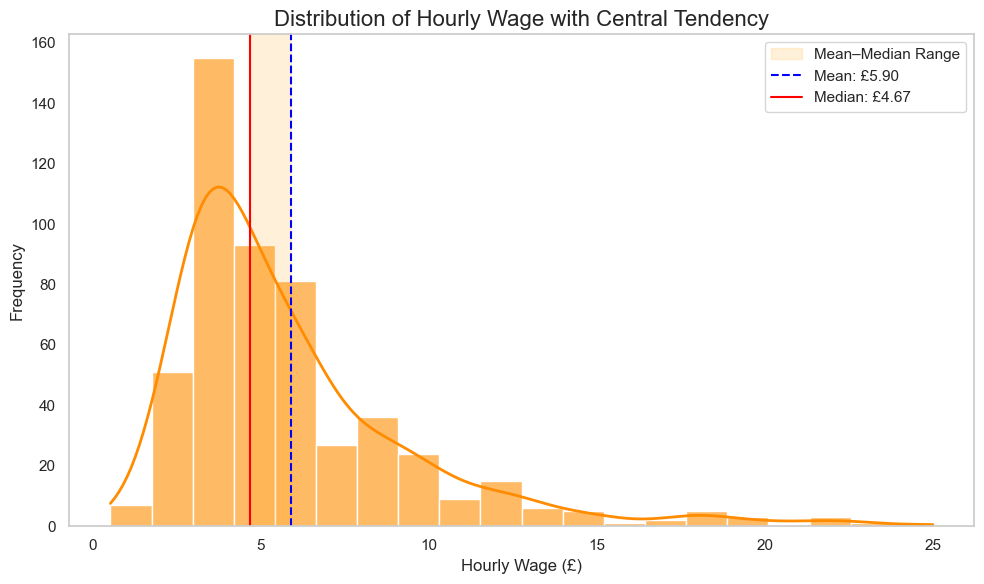

In [23]:
# Calculate key statistics
mean_wage = df1["hourly_wage"].mean()
median_wage = df1["hourly_wage"].median()

# Create figure
plt.figure(figsize=(10, 6))

# Plot histogram + KDE
sns.histplot(
    df1["hourly_wage"],
    kde=True,
    bins=20,
    color="darkorange",
    alpha=0.6,
    line_kws={'linewidth': 2}
)

# --- Shade the region between Median and Mean ---
plt.axvspan(
    min(mean_wage, median_wage),
    max(mean_wage, median_wage),
    color='Orange',
    alpha=0.15,
    label="Mean–Median Range"
)

# Mean line
plt.axvline(mean_wage, color='blue', linestyle='--', linewidth=1.5,
            label=f"Mean: £{mean_wage:.2f}")

# Median line
plt.axvline(median_wage, color='red', linestyle='-', linewidth=1.5,
            label=f"Median: £{median_wage:.2f}")

# To Remove gridlines
plt.grid(False)

# Titles and labels
plt.title("Distribution of Hourly Wage with Central Tendency", fontsize=16)
plt.xlabel("Hourly Wage (£)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Legend
plt.legend()

plt.tight_layout()
plt.show()


**Interpretation**:This distribution of hourly wages is strongly right-skewed, with most employees earning between £3 and £8 per hour. The median wage (£4.67) is lower than the mean wage (£5.90), and the shaded region between these two values highlights the skew caused by a smaller number of higher earners pulling the average upward. This indicates that while a few individuals earn substantially more, the majority earn below the overall average. The smooth density curve further confirms the long right tail, reinforcing the presence of high-wage outliers.

## B. Effect of Education and Employment Duration on Hourly wage

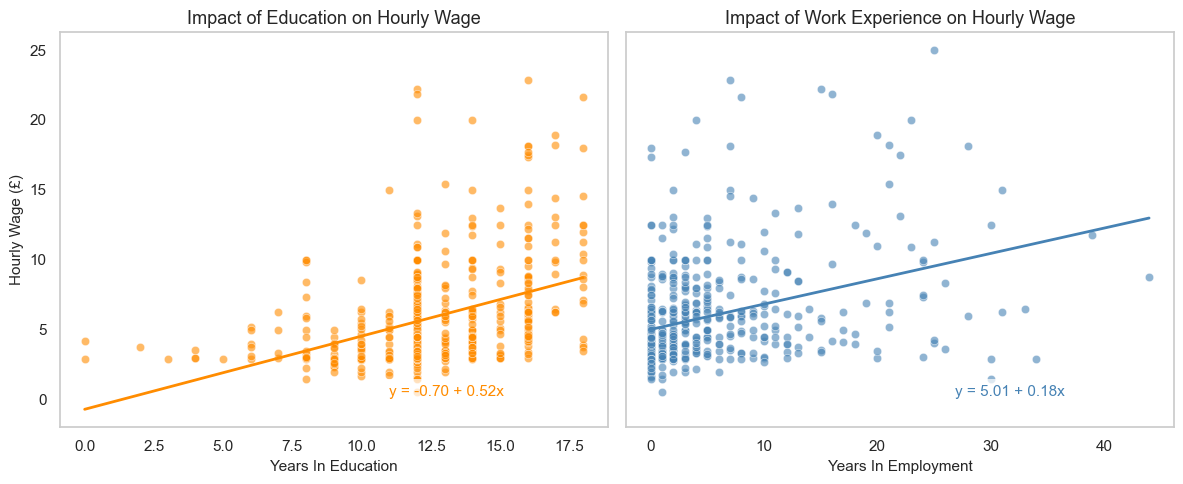

In [174]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

plots = [
    ("years_in_education",  "hourly_wage",
     "Impact of Education on Hourly Wage", "darkorange", axes[0]),
    ("years_in_employment", "hourly_wage",
     "Impact of Work Experience on Hourly Wage", "steelblue", axes[1])
]

for x, y, title, color, ax in plots:
    
    data_xy = df1[[x, y]].dropna()

    # --- fit regression model ---
    X = sm.add_constant(data_xy[x])
    model = sm.OLS(data_xy[y], X).fit()

    # use label names for coefficients
    alpha = model.params["const"]   # intercept
    beta  = model.params[x]         # slope

    # regression line
    x_vals = np.linspace(data_xy[x].min(), data_xy[x].max(), 100)
    y_vals = alpha + beta * x_vals

    # scatterplot
    sns.scatterplot(data=data_xy, x=x, y=y, color=color, alpha=0.6, ax=ax)

    # regression line
    ax.plot(x_vals, y_vals, color=color, linewidth=2)

    # equation label near the right end of the line
    eq_text = f"y = {alpha:.2f} + {beta:.2f}x"
    ax.text(
        0.60, 0.08, eq_text,
        transform=ax.transAxes,
        fontsize=11,
        color=color,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

    # titles and labels
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(x.replace("_", " ").title(), fontsize=11)
    ax.set_ylabel("Hourly Wage (£)", fontsize=11)

    # remove grid
    ax.grid(False)

plt.tight_layout()
plt.show()



**Interpretation:** The first plot, showing education vs hourly wage, reveals a positive but relatively weak relationship. As years of education increase, hourly wages tend to rise, but the points are widely scattered, indicating large variation among individuals with similar education levels. The regression line, y=−0.70+0.52x, suggests that each additional year of education is associated with roughly a £0.52 increase in hourly wage, although the spread of data indicates education alone does not fully explain wage differences.

The second plot, showing employment experience vs hourly wage, also displays a positive trend but with even more variability. The fitted line,
y=5.01+0.18x, indicates a smaller wage increase of about £0.18 per additional year of employment. While wages generally rise with experience, the points are more dispersed, and many individuals with long employment histories still earn relatively modest wages.

**Overall conclusion:** Both education and work experience show positive but modest associations with hourly wages. Education appears to have a slightly stronger effect than employment duration, but neither variable alone strongly predicts wage outcomes—highlighting the influence of additional factors not captured in these plots.

## **C. Comparison of Hourly Wages Across Gender Groups**

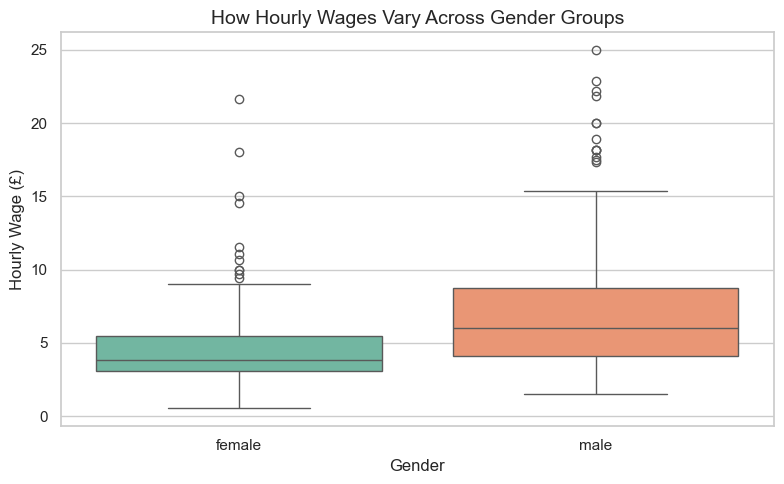

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df1,
    x="gender",
    y="hourly_wage",
    hue="gender",     # required to avoid future warnings
    palette="Set2",
    legend=False      # prevents duplicate legends
)

plt.title("How Hourly Wages Vary Across Gender Groups", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Hourly Wage (£)", fontsize=12)

plt.tight_layout()
plt.show()


**Interprepation**: This boxplot above compares the distribution of hourly wages between males and females in the dataset. It is clear in graph that male workers earn higher hourly wages on average than female workers.
The median hourly wage for males is visibly higher than that of females, and the interquartile range (IQR) is also shifted upward, indicating that typical male wages are consistently above typical female wages. Furthermore, the distribution for males extends further into the higher wage ranges, with several outliers above £15 and even reaching beyond £20–£25 per hour. In contrast, female wages are more tightly concentrated between £3 and £7, with far fewer high-wage observations.
These differences suggest a gender wage gap within the dataset, with males earning more across the distribution, not only at the median but also in the upper tail. This observation aligns with broader economic findings about gender-based pay differences. The visual evidence here strongly supports the conclusion that gender is an important factor in explaining wage variation among the individuals in the dataset.

## **D. Heatmap of Interrelationships Among Continuous Variables**

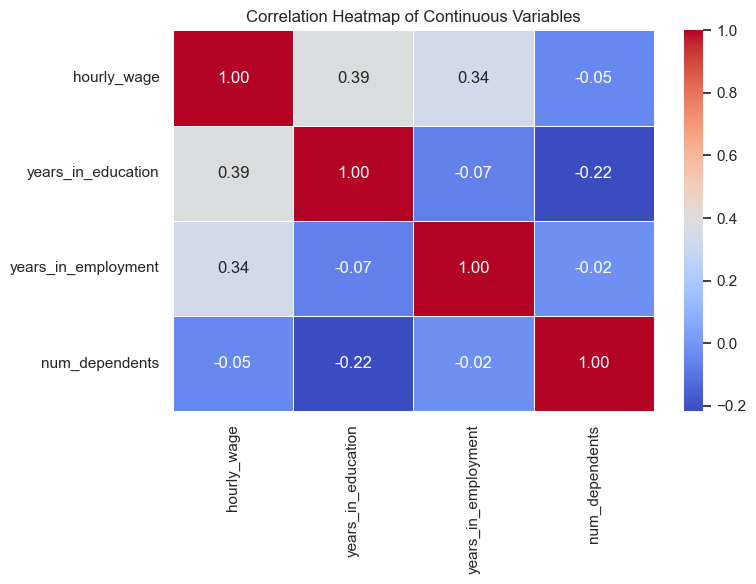

In [26]:
# Select continuous variables
cont_vars = ["hourly_wage", "years_in_education", 
             "years_in_employment", "num_dependents"]

# Compute correlation matrix
corr_matrix = df1[cont_vars].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Continuous Variables")
plt.tight_layout()
plt.show()

**Interpretation:** This heatmap shows that years in education (r ≈ 0.39) and years in employment (r ≈ 0.34) have moderate positive correlations with hourly wage, indicating that higher education and more work experience are generally associated with higher earnings. In contrast, number of dependents shows almost no meaningful correlation with any variable, suggesting it does not influence wage or the other continuous factors in this dataset.

## **4. Unique values and frequencies of a categorical variable**

In [98]:
print("Unique values in 'gender':", df1['gender'].unique())
print("\nFrequency counts:")
print(df1['gender'].value_counts())
print("\nRelative frequencies (%):")
print(df1['gender'].value_counts(normalize=True) * 100)


Unique values in 'gender': ['female' 'male']

Frequency counts:
gender
male      276
female    249
Name: count, dtype: int64

Relative frequencies (%):
gender
male      52.571429
female    47.428571
Name: proportion, dtype: float64


The gender variable contains two unique categories: male and female. The distribution is relatively balanced, with 276 males (52.6%) and 249 females (47.4%) in the dataset. This near-even split indicates that gender-based comparisons, such as differences in hourly wages, can be made without strong concerns about sample imbalance.
The balanced representation strengthens the validity of subsequent gender-based statistical analyses.

## **5. Contingency Table and Chi-Square Test of Independence**

In [29]:
# This table has been created below to examine the relationship between gender and marital status:**

table = pd.crosstab(df1["gender"], df1["married"])
print("Contingency Table (Gender x Married):")
print(table)

Contingency Table (Gender x Married):
married  0.0  1.0
gender           
female   118  131
male      86  190


This table shows that a greater proportion of males are married compared with females. To determine whether this observed difference is statistically significant, a Chi-Square test of independence has been conducted below.

## Chi-Square Test

**Hypotheses**

**H₀ (Null hypothesis):** Gender and marital status are not associated.

**H₁ (Alternative hypothesis):** Gender and marital status are associated.

In [13]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-Square Test Results:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.6f}")

print("\nExpected Frequencies (if variables were independent):")
print(pd.DataFrame(expected, index=table.index, columns=table.columns))



Chi-Square Test Results:
Chi-square statistic: 13.3913
Degrees of freedom: 1
P-value: 0.000253

Expected Frequencies (if variables were independent):
married         0.0         1.0
gender                         
female    97.189189  150.810811
male     105.810811  164.189189


**Interpretation:** The p-value obtained **(p ≈ 0.000253)** is far below the conventional significance level of 0.05.Because the p-value is extremely small, **we reject the null hypothesis of independence between gender and marital status**. This means there is strong statistical evidence that gender and marital status are not independent in this dataset. The likelihood of being married differs between males and females. Males in this dataset are more likely to be married, while females are more likely to be unmarried, compared to what would be expected if the two variables were unrelated.

These results highlight a significant association between gender and marital status within this sample, suggesting underlying social or demographic factors influencing marital patterns across genders.

## **6. Threshold-Based Subsetting of the Dataset**

In [4]:
# Defined threshold values for what counts as HIGH or LOW
# These cut-offs help us meaningfully separate the dataset into two groups.

high_edu = 14      # 14+ years = high education
low_edu = 11       # 0–11 years = low education

high_emp = 10      # 10+ years = high employment
low_emp = 5        # 0–5 years = low employment

In [30]:
#Created Group 1: High Education + Low Employment
# These people stayed longer in education, so they started working later.
# We call them "Late Starters" because they enter the workforce later.

late_starters = df1[
    (df1["years_in_education"] >= high_edu) &    # high education
    (df1["years_in_employment"] <= low_emp)      # low employment
]

In [31]:
#Created Group 2: Low Education + High Employment
# These people left education earlier and entered the workforce sooner.
# We call them "Early Starters".

early_starters = df1[
    (df1["years_in_education"] <= low_edu) &     # low education
    (df1["years_in_employment"] >= high_emp)     # high employment
]

In [32]:
#Show how many people are in each group

print("Late Starters (high education, low employment):", late_starters.shape[0])
print("Early Starters (low education, high employment):", early_starters.shape[0])

Late Starters (high education, low employment): 130
Early Starters (low education, high employment): 27


## Descriptive statistics for each subset

In [33]:
print("Late starters (high edu, low employment) - numeric summary:\n")
print(late_starters[["hourly_wage", "years_in_education", 
                     "years_in_employment", "num_dependents"]].describe())

print("\nEarly starters (low edu, high employment) - numeric summary:\n")
print(early_starters[["hourly_wage", "years_in_education", 
                      "years_in_employment", "num_dependents"]].describe())


Late starters (high edu, low employment) - numeric summary:

       hourly_wage  years_in_education  years_in_employment  num_dependents
count   130.000000          130.000000           130.000000      130.000000
mean      6.690077           15.500000             1.869231        0.746154
std       3.208770            1.265217             1.653694        0.950818
min       2.920000           14.000000             0.000000        0.000000
25%       4.410000           14.000000             0.000000        0.000000
50%       6.040000           16.000000             2.000000        0.000000
75%       8.532500           16.000000             3.000000        1.750000
max      18.000000           18.000000             5.000000        4.000000

Early starters (low edu, high employment) - numeric summary:

       hourly_wage  years_in_education  years_in_employment  num_dependents
count    27.000000           27.000000            27.000000       27.000000
mean      5.034074            7.962963  

**Comparison of Subsets: Late Starters vs Early Starters**
Two meaningful subsets were extracted from the dataset based on education and employment experience. “Late starters” were defined as individuals with high education (14+ years) but low employment experience (≤ 5 years), while “early starters” were defined as those with low education (≤ 11 years) and high employment experience (≥ 10 years).

**The descriptive statistics reveal clear differences between the groups -**
Late starters have substantially higher education levels (mean ≈ 15.5 years) and relatively little employment experience (mean ≈ 1.9 years). They also earn higher hourly wages on average (£6.69).
Early starters show the opposite pattern: lower education (mean ≈ 7.96 years), much greater work experience (mean ≈ 18.8 years), and lower hourly wages (£5.03). They also tend to have slightly more dependents.

This comparison shows that education has a stronger influence on wage levels than employment experience in this dataset. Late starters earn more despite having far fewer years of employment, while early starters earn less even with significantly more experience.

## **7. T-test Comparing Hourly Wages Between Late Starters and Early Starters**

To examine whether hourly wages differ between “late starters” (high education, low employment) and “early starters” (low education, high employment), an independent two-sample t-test was conducted. The hypotheses for this analysis were:

**Hypothesis**

**(H₀):** There is no significant difference in the mean hourly wage between late starters and early starters

**(H₁):** There is a significant difference in the mean hourly wage between late starters and early starters

In [34]:
# Define the two groups
group1 = late_starters["hourly_wage"]      # High education, low employment
group2 = early_starters["hourly_wage"]     # Low education, high employment

# Import t-test function
from scipy import stats

# Perform independent two-sample t-test
t_val, p_val = stats.ttest_ind(group1, group2, equal_var=False)

# Print results in class format
print(f"t-value: {t_val}")
print(f"p-value: {p_val}")

t-value: 2.8746211711527843
p-value: 0.006210612312481541


**Interpretation:** The average hourly wage for late starters was £6.69, whereas early starters earned on average £5.05 per hour. The t-test produced a t-value of 2.87 and a p-value of 0.0062. Because the p-value (0.0062) is well below the conventional 5% significance level, **we reject the null hypothesis** of equal mean wages and conclude that there is a statistically significant difference in hourly wages between late starters and early starters. Moreover, since the t-value is positive and the mean wage of late starters is higher, the results suggest that individuals who invest more time in education before entering the labour market tend to earn higher hourly wages than those who start working earlier with lower.

## **8. Grouped Summary Analysis by a Categorical Variable**

To extend the exploratory analysis, a grouped summary was performed to examine how hourly wages differ across categories of a meaningful variable. For this purpose, gender was selected as the grouping variable because earlier visual analysis suggested visible wage differences between male and female respondents.

In [29]:
# Grouped Summary by Categorical Variable (Gender)

group_summary = df1.groupby("gender")["hourly_wage"].agg(
    ["count", "mean", "median", "std"])

In [31]:
print("Hourly Wage Summary by Gender:")
print(group_summary)

Hourly Wage Summary by Gender:
        count      mean  median       std
gender                                   
female    249  4.608353    3.81  2.486611
male      276  7.062862    6.00  4.156322


**Interpreptation:** The grouped summary shows clear differences in hourly wages between males and females. On average, males earn £7.06 per hour, while females earn £4.61 per hour, indicating a noticeable gender pay gap in this dataset. The median wages (£6.00 for males vs. £3.81 for females) further reinforce this pattern, suggesting that the typical male employee earns substantially more than the typical female employee. The standard deviations (4.15 for males and 2.49 for females) show that wages for males vary more widely, with some earning considerably higher than the average. Overall, this grouped analysis suggests that gender is meaningfully associated with wage differences.

## **9. Multiple Linear Regression: Predicting Hourly Wage**

A multiple linear regression model has been estimated to explain variation in hourly wage using years in education, years in employment, number of dependents, marital status, gender, and race as predictors.

In [28]:
# Build a multiple linear regression model for hourly wage

import statsmodels.api as sm

# Use statsmodels' formula interface.
# C() tells statsmodels that the variable is categorical.
formula = "hourly_wage ~ years_in_education + years_in_employment + num_dependents + C(married) + C(gender) + C(race)"

model = sm.OLS.from_formula(formula, data=df1).fit()


In [29]:
# To Show full regression summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            hourly_wage   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.341
Method:                 Least Squares   F-statistic:                     46.17
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           2.71e-45
Time:                        19:46:12   Log-Likelihood:                -1315.1
No. Observations:                 525   AIC:                             2644.
Df Residuals:                     518   BIC:                             2674.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.8196      0.761     -3.705      0.000      -4.315      -1.324
C(married)[T.1.0]       0.7393      0.283      2.610      0.009       0.183       1.296
C(gender)[T.male]       1.6918      0.269      6.293      0.000       1.164       2.220
C(race)[T.white]       -0.0140      0.432     -0.032      0.974      -0.863       0.835
years_in_education      0.5191      0.049     10.531      0.000       0.422       0.616
years_in_employment     0.1506      0.019      7.945      0.000       0.113       0.188
num_dependents          0.0983      0.109      0.904      0.366      -0.115       0.312
==============================================================================
Omnibus:                      208.236   Durbin-Watson:                   1.814
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              903.685
Skew:                           1.758   Prob(JB):                    5.85e-197
Kurtosis:                       8.380   Cond. No.                         86.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Interpretation:** The regression model explains around 34.8% of the variation in hourly wage (R² = 0.348), indicating a moderate ability to predict wages using the chosen variables. Several predictors show statistically significant effects. Years in education has a strong positive relationship with hourly wage (β = 0.5191, p < 0.001), meaning that each additional year of education is associated with an increase of roughly £0.52 in hourly pay. Years in employment also shows a positive and significant effect (β = 0.1506, p < 0.001), suggesting that experience contributes meaningfully to higher wages. Among categorical variables, being married is linked with higher wages (β = 0.7393, p = 0.009), and being male is also associated with higher hourly earnings (β = 1.6918, p < 0.001). The results indicated that race (p = 0.974) and number of dependents (p = 0.366) were not statistically significant predictors of hourly wage at the 5% significance level. **Because including non-significant predictors can inflate model complexity, reduce interpretability, and may slightly decrease predictive efficiency, the model has been refined below by removing the two non-significant variables (race and number of dependents)**.

## Updated Regression Model

In [30]:
# Updated model without race and number of dependents
updated_model = sm.OLS.from_formula(
    "hourly_wage ~ C(married) + C(gender) + years_in_education + years_in_employment",
    data=df1
).fit()

updated_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            hourly_wage   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     69.21
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           5.85e-47
Time:                        19:46:20   Log-Likelihood:                -1315.6
No. Observations:                 525   AIC:                             2641.
Df Residuals:                     520   BIC:                             2662.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.6165      0.632     -4.140      0.000      -3.858      -1.375
C(married)[T.1.0]       0.7845      0.278      2.827      0.005       0.239       1.330
C(gender)[T.male]       1.6889      0.268      6.292      0.000       1.162       2.216
years_in_education      0.5085      0.048     10.643      0.000       0.415       0.602
years_in_employment     0.1493      0.019      7.912      0.000       0.112       0.186
==============================================================================
Omnibus:                      208.392   Durbin-Watson:                   1.819
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              906.638
Skew:                           1.758   Prob(JB):                    1.34e-197
Kurtosis:                       8.392   Cond. No.                         69.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The updated model shows that marital status, gender, education, and employment experience all significantly predict hourly wage, with education and employment being the strongest contributors (p < 0.001). The positive coefficients indicate that each additional year of education (£0.51) and experience (£0.15) increases hourly wage on average. The Jarque-Bera statistic (≈ 906, p < 0.001) indicates that the residuals are not normally distributed, meaning the model fits reasonably well but violates the normality assumption—which is common in wage data due to right-skewness.

**Wage Calculator**

Hourly Wage=−2.6165+0.7045(Married)+1.6889(Male)+0.5085(Years Ed)+0.1493(Years Emp)

**Example:**
If married=1, male=0, years_ed=12, years_emp=5

Then, Hourly Wage=−2.6165+0.7045*1+1.6889*0+0.5085*12+0.1493*5 = **4.89 Per Hour**

## Regression Diagnostics

In [53]:
# Calculate standardized residuals for diagnostics
influence = updated_model.get_influence()
standard_residuals = influence.resid_studentized_internal
fitted_values = updated_model.fittedvalues


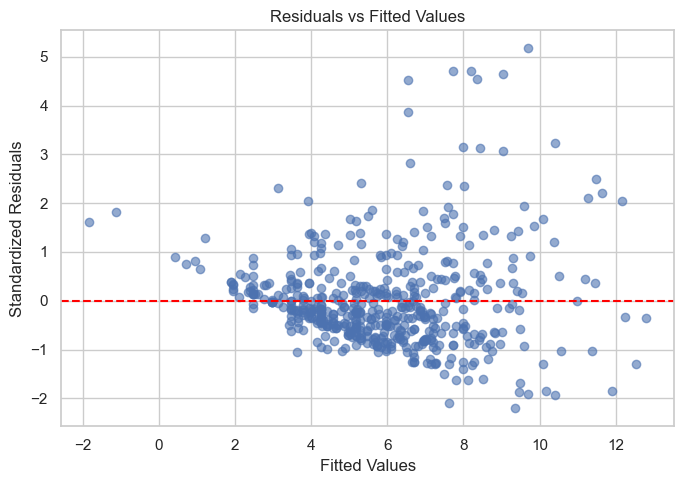

In [55]:
# --- Plot 1: Residuals vs Fitted Values ---

plt.figure(figsize=(7, 5))
plt.scatter(fitted_values, standard_residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()


**Interpretation:** The residuals are mostly scattered around zero, which suggests the model captures the general trend in the data. However, there are several noticeable outliers far away from the main cloud of points. This pattern suggests that the dataset contains genuine extreme wage values, and the linear model struggles to explain them fully. These outliers may reflect people with rare job roles, exceptional skills, or unmeasured factors, which are not included in the dataset but strongly influence wages.

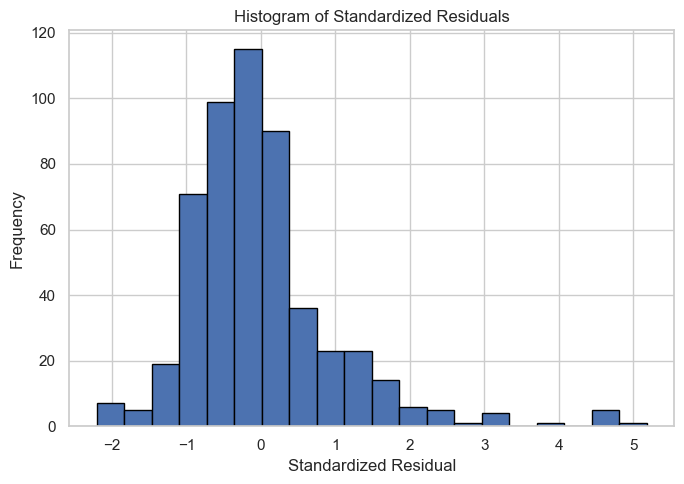

In [57]:
# --- Plot 2: Histogram of Standardized Residuals ---

plt.figure(figsize=(7, 5))
plt.hist(standard_residuals, bins=20, edgecolor="black")
plt.title("Histogram of Standardized Residuals")
plt.xlabel("Standardized Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** The histogram shows that most standardized residuals cluster around 0, which is good—it means the model predicts reasonably well for the majority of individuals. However, the distribution is noticeably right-skewed, with several residuals extending above +3 and even +5. These large positive residuals indicate specific observations in the dataset where the model seriously under-predicted the hourly wage, meaning those individuals earn much higher wages than the model expected based on their education, experience, gender, and marital status. These extreme cases create non-normality in the residuals and suggest that the dataset contains a small number of very high-earning individuals who do not follow the general trend. Such outliers reduce the accuracy of the regression model and may require further investigation or transformation.

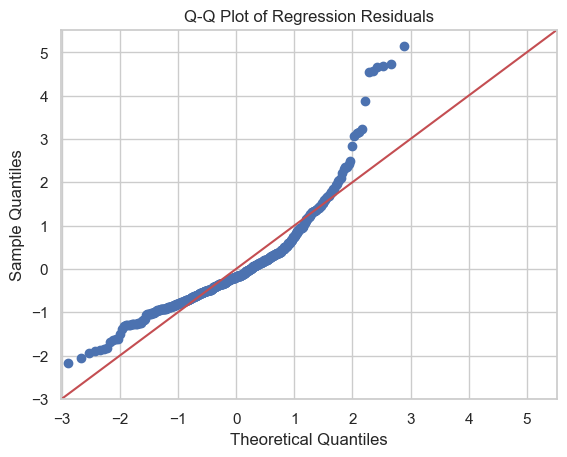

In [63]:
# --- Q-Q Plot for Normality of Residuals ---

# Get residuals from updated model
residuals = updated_model.resid

fig = sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Regression Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()


**Interpretation:** The Q-Q plot shows that the residuals follow the expected straight line fairly well in the middle portion of the distribution, indicating that most hourly-wage predictions are reasonably close to normal. However, there is a clear deviation at the upper end (right tail). Several observations rise far above the diagonal line, meaning the model produces large positive residuals for a small group of individuals. These are the same high-wage outliers already seen in earlier plots: a few respondents in the dataset earn £20–£25 per hour, which is unusually high compared to the rest of the sample. Because these extreme wages are real values in the dataset, not coding errors, they naturally pull the right tail upward and cause non-normality.

In summary: normality holds in the centre but fails at the upper tail due to genuine high-income outliers present in the dataset

### **Acknowledgement**

I would like to acknowledge the use of AI assistance (ChatGPT) during the development of this report. AI tools were used to enhance the clarity and visual presentation of certain plots (for example, in Sections 3A and 3B) and to help diagnose and correct coding errors that occurred during the analysis process.